<a href="https://colab.research.google.com/github/sei-latam/WETSAT_v2/blob/main/2_Modelling_WETSAT_Google_Colab/User_Version_Kmeans_WetSAT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Google Colaboratory\
GitHub\
Wetlands flooding extent and trends using SATellite data and Machine Learning WETSAT\
Please cite as follow:\
Palomino-Ángel, S., Méndez, C., Zamora, D., Santos, T., Prasad, S., and Piman, T. (2025). WetSAT-ML: Wetlands flooding extent and trends using SATellite data and Machine Learning (Version 1.0) [Data System]. Stockholm Environment Institute (SEI). https://github.com/sei-latam/WETSAT_v2.

# **User Version K-means Model **

# Install packages and libraries used in WETSAT


In [ ]:
###################################### Artificial Intelligence Frameworks #####################################################
# scikit-learn Framework
!pip install scikit-learn
###################################### Data, Geoprocessing and Graphics libraries #####################################################
!pip install rasterio
!pip install matplotlib
!pip install numpy
!pip install contextily
!pip install pandas

# Import libraries and packages

In [ ]:
## AI packages
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.preprocessing import RobustScaler

## Processing packages
import os # Provides functions to interact with the operating system (paths, directories).
import re # Regular expressions for pattern matching filenames.
import random # Random number generation (used for sampling pixels)
import warnings # To manage warning messages.
from glob import glob # Utility to find files matching a pattern in directories.
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

import joblib          # For saving/loading Python objects (scaler, KMeans model).
import numpy as np     # Numerical computing library (arrays, math).
import pandas as pd    # Data manipulation library (tables, CSV export).
import rasterio        # Library to read/write raster (GeoTIFF) files.
from rasterio.errors import NotGeoreferencedWarning  # Specific warning type to suppress.

warnings.filterwarnings("ignore", category=NotGeoreferencedWarning)

from collections import Counter
from google.colab import files
from google.colab import data_table
import urllib.request

# Create Buttoms and import files

## Create Buttom to upload VH Images

In [ ]:
# Define vh_path
vh_path = "/content/WetSAT/VH"

# Create vh path if doesn't exist
os.makedirs(vh_path, exist_ok=True)

# Upload files
uploadvh = files.upload()

# Store files in the VH path
for filename, content in uploadvh.items():
    file_path = os.path.join(vh_path, filename)
    with open(file_path, "wb") as f:
        f.write(content)
    print(f"Files stored in: {file_path}")

Saving gamma_dB_20240101_VH_sample.tif to gamma_dB_20240101_VH_sample.tif
Saving gamma_dB_20240113_VH_sample.tif to gamma_dB_20240113_VH_sample.tif
Saving gamma_dB_20240125_VH_sample.tif to gamma_dB_20240125_VH_sample.tif
Saving gamma_dB_20240206_VH_sample.tif to gamma_dB_20240206_VH_sample.tif
Saving gamma_dB_20240218_VH_sample.tif to gamma_dB_20240218_VH_sample.tif
Files stored in: /content/WetSAT/VH/gamma_dB_20240101_VH_sample.tif
Files stored in: /content/WetSAT/VH/gamma_dB_20240113_VH_sample.tif
Files stored in: /content/WetSAT/VH/gamma_dB_20240125_VH_sample.tif
Files stored in: /content/WetSAT/VH/gamma_dB_20240206_VH_sample.tif
Files stored in: /content/WetSAT/VH/gamma_dB_20240218_VH_sample.tif


## Create Buttom to upload VV Images

In [ ]:
# Define vv_path
vv_path = "/content/WetSAT/VV"

# Create vv path if doesn't exist
os.makedirs(vv_path, exist_ok=True)

# Upload files
uploadvv = files.upload()

# Store files in the VH path
for filename, content in uploadvv.items():
    file_path = os.path.join(vv_path, filename)
    with open(file_path, "wb") as f:
        f.write(content)
    print(f"Files stored in: {file_path}")

Saving gamma_dB_20240101_VV_sample.tif to gamma_dB_20240101_VV_sample.tif
Saving gamma_dB_20240113_VV_sample.tif to gamma_dB_20240113_VV_sample.tif
Saving gamma_dB_20240125_VV_sample.tif to gamma_dB_20240125_VV_sample.tif
Saving gamma_dB_20240206_VV_sample.tif to gamma_dB_20240206_VV_sample.tif
Saving gamma_dB_20240218_VV_sample.tif to gamma_dB_20240218_VV_sample.tif
Files stored in: /content/WetSAT/VV/gamma_dB_20240101_VV_sample.tif
Files stored in: /content/WetSAT/VV/gamma_dB_20240113_VV_sample.tif
Files stored in: /content/WetSAT/VV/gamma_dB_20240125_VV_sample.tif
Files stored in: /content/WetSAT/VV/gamma_dB_20240206_VV_sample.tif
Files stored in: /content/WetSAT/VV/gamma_dB_20240218_VV_sample.tif


### Calculate the PR index in new AOI

In [5]:
## Access the VH Path
vh_path = "/content/WetSAT/VH"
## Access the VV Path
vv_path = "/content/WetSAT/VV"
## Create the PR Index path
pr_path = "/content/WetSAT/PR_index"

# Create output directory if it doesn't exist
os.makedirs(pr_path, exist_ok=True)

# List VH and VV files (assuming matching filenames)
vh_files = sorted([f for f in os.listdir(vh_path) if f.endswith(".tif")]) # Search files ending with .tif
vv_files = sorted([f for f in os.listdir(vv_path) if f.endswith(".tif")]) # Search files ending with .tif

# Loop through files and compute PR index scaled between 0 and 1
for vh_file, vv_file in zip(vh_files, vv_files):
    # Read the vh_files and vv_files
    with rasterio.open(os.path.join(vh_path, vh_file)) as vh_src, \
         rasterio.open(os.path.join(vv_path, vv_file)) as vv_src:

        vh = vh_src.read(1).astype("float32") # Converts the data to 32-bit float
        vv = vv_src.read(1).astype("float32") # Converts the data to 32-bit float

        pr_index_diff = vv - vh  # Compute PR index as difference

        # Save PR index difference
        profile = vh_src.profile
        profile.update(dtype="float32", count=1)

        pr_filename = f"PR_diff_{vh_file}"
        with rasterio.open(os.path.join(pr_path, pr_filename), "w", **profile) as dst:
            dst.write(pr_index_diff, 1)

print("PR index (VV - VH) computation complete.")

PR index (VV - VH) computation complete.


# Create Multibands Images (VV,VH and PR)

In [6]:
# Create Output path
multi_dir = "/content/WetSAT/data_cut_dB"
os.makedirs(multi_dir, exist_ok=True)

# List VH, VV and PR files (assuming matching filenames)
vh_files = sorted([f for f in os.listdir(vh_path) if f.endswith(".tif")])
vv_files = sorted([f for f in os.listdir(vv_path) if f.endswith(".tif")])
pr_files = sorted([f for f in os.listdir(pr_path) if f.endswith(".tif")])

# Create looping to create multiband images
for vh_file, vv_file, pr_file in zip(vh_files, vv_files, pr_files):
    # Open the vv,vh and pr files
    with rasterio.open(os.path.join(vv_path, vv_file)) as vv_src, \
         rasterio.open(os.path.join(vh_path, vh_file)) as vh_src, \
         rasterio.open(os.path.join(pr_path, pr_file)) as pr_src:

        # Converts the data to 32-bit float
        vv = vv_src.read(1).astype("float32")
        vh = vh_src.read(1).astype("float32")
        pr = pr_src.read(1).astype("float32")

        # Create profile output with 3 bands (vv,vh and pr)
        profile = vv_src.profile
        profile.update(dtype="float32", count=3)

        # Create ouput file name based in: YYYY/MM/DD_multi.tif
        # Use example of VV to rename files
        date = re.search(r"(20\d{6})", vv_file).group(1)
        out_name = f"{date}_multi.tif"
        out_path = os.path.join(multi_dir, out_name) # Set path and names

        with rasterio.open(out_path, "w", **profile) as dst:
            dst.write(vv, 1)  # Band 1: VV
            dst.write(vh, 2)  # Band 2: VH
            dst.write(pr, 3)  # Band 3: PR

    print(f"Multiband image (vv,vh and pr) create with the name: {out_name}")

print("\n The process to create stack multibands (VV, VH y PR) finished.")

Multiband image (vv,vh and pr) create with the name: 20240120_multi.tif
Multiband image (vv,vh and pr) create with the name: 20240213_multi.tif
Multiband image (vv,vh and pr) create with the name: 20240320_multi.tif
Multiband image (vv,vh and pr) create with the name: 20240413_multi.tif
Multiband image (vv,vh and pr) create with the name: 20240519_multi.tif
Multiband image (vv,vh and pr) create with the name: 20240612_multi.tif
Multiband image (vv,vh and pr) create with the name: 20240718_multi.tif
Multiband image (vv,vh and pr) create with the name: 20240823_multi.tif
Multiband image (vv,vh and pr) create with the name: 20240916_multi.tif
Multiband image (vv,vh and pr) create with the name: 20241022_multi.tif
Multiband image (vv,vh and pr) create with the name: 20241115_multi.tif
Multiband image (vv,vh and pr) create with the name: 20241221_multi.tif

 The process to create stack multibands (VV, VH y PR) finished.


## Create directory when data will be stored

In [7]:
DATA_DIR = "/content/WetSAT/data_cut_dB"
PATTERN  = re.compile(r"^(\d{8})_multi\.tif$", re.IGNORECASE)

# Import the Kmeans Models and Scalers

In [8]:
# Create backup from GitHub to import K-means model
# Load K-means model
model_url = "https://raw.githubusercontent.com/sei-latam/WETSAT_v2/main/2_Modelling_WETSAT_Google_Colab/Model_Kmeans.joblib"
urllib.request.urlretrieve(model_url, "/content/WetSAT/data_cut_dB/Model_Kmeans.joblib")
kmeans = joblib.load("/content/WetSAT/data_cut_dB/Model_Kmeans.joblib")

# Load Scalers
scaler_url = "https://raw.githubusercontent.com/sei-latam/WETSAT_v2/main/2_Modelling_WETSAT_Google_Colab/Labels_Scaler_Kmeans.joblib"
urllib.request.urlretrieve(scaler_url, "/content/WetSAT/data_cut_dB/Labels_Scaler_Kmeans.joblib")
scaler = joblib.load("/content/WetSAT/data_cut_dB/Labels_Scaler_Kmeans.joblib")

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator KMeans from version 1.0.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator RobustScaler from version 1.0.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


## Visualize Kmeans model

In [9]:
kmeans

KMeans(algorithm='auto', n_clusters=5, n_init=10, random_state=42)

## Visualize Clusters and Centroids

In [10]:
print("Number of clusters:", kmeans.n_clusters)
print("Centroid (in normalized space):")
print(kmeans.cluster_centers_)

Number of clusters: 5
Centroid (in normalized space):
[[  0.25175595   0.2017641    0.12446242]
 [-21.696985   -19.891098    -2.09989   ]
 [ -6.1808124   -5.625261    -0.5906805 ]
 [ -1.3137195   -0.71640384  -0.56257814]
 [-13.543598   -13.184584    -0.4963554 ]]


## Upload Scaler path

In [11]:
SCALER_PATH = os.path.join(DATA_DIR, "Labels_Scaler_Kmeans.joblib")
MODEL_PATH  = os.path.join(DATA_DIR, "Model_Kmeans.joblib")

OUTPUT_SUFFIX = "_class.tif"   # Labels 1-5
OVERWRITE = True

# Create functions for classification

In [12]:
def list_multis(folder):
    # Define a function that lists all raster files ending with "_multi.tif" in a given folder.
    files = sorted(glob(os.path.join(folder, "*_multi.tif")))
    # Use glob to find all files matching the pattern "*_multi.tif" inside the folder.
    # sorted() ensures the list is ordered alphabetically (useful for reproducibility).
    items = []
    # Initialize an empty list to store (date, filepath) tuples.
    for f in files:
        # Iterate through each file found.
        name = os.path.basename(f)
        # Extract just the filename (without directory path).
        m = PATTERN.match(name)
        # Apply the regex pattern defined earlier (PATTERN) to check if filename matches "YYYYMMDD_multi.tif".
        if m:
            # If the filename matches the expected pattern:
            date = m.group(1)
            # Extract the date string (first capturing group in regex, i.e., YYYYMMDD).
            items.append((date, f))
            # Store a tuple (date, full filepath) in the items list.
    return items
    # Return the list of tuples. Each element contains the acquisition date and the file path.

def classify_one(path, scaler, kmeans):
    """
    Classifies a multiband image (VV, VH, PR), returning:
    - labels_uint8: raster of cluster labels (uint8)
    - meta_output: metadata dictionary for saving output raster
    """
    with rasterio.open(path) as src:
        # Open the raster file using rasterio (context manager ensures proper closing).
        if src.count < 3:
            # Check that the raster has at least 3 bands (VV, VH, PR).
            raise ValueError(f"{os.path.basename(path)} The image doesn´t have three bands (VV,VH,PR).")
        vv = src.read(1).astype(np.float32)
        vh = src.read(2).astype(np.float32)
        pr = src.read(3).astype(np.float32)
        # Read bands 1, 2, and 3 as float32 arrays:
        # Band 1 = VV, Band 2 = VH, Band 3 = PR.
        nodata = src.nodata  # de VV, por diseño
        # Get the NoData value defined in the raster (usually from band 1).
        if nodata is not None:
            mask = (vv != nodata)
            # If NoData is defined, mask out pixels equal to nodata in VV.
        else:
            mask = np.isfinite(vv) & np.isfinite(vh) & np.isfinite(pr)
            # Otherwise, mask out any non-finite values (NaN, inf) across all bands.
        mask &= np.isfinite(vv) & np.isfinite(vh) & np.isfinite(pr)
        # Ensure mask excludes any non-finite values in all three bands.
        H, W = vv.shape
        # Get raster dimensions (height and width).
        X = np.stack([vv, vh, pr], axis=2).reshape(-1, 3)
        # Stack the three bands into a 3D array (H, W, 3).
        # Then reshape into a 2D array of shape (H*W, 3), where each row = pixel vector [VV, VH, PR].
        valid_idx = mask.reshape(-1)
        # Flatten the mask to match the reshaped pixel array.
        X_valid = X[valid_idx]
        # Extract only valid pixels (those not masked).
        X_scaled = scaler.transform(X_valid)
        # Apply the trained scaler (RobustScaler) to normalize valid pixel values.

        labels = kmeans.predict(X_scaled)  # 0..K-1
        # Predict cluster labels using the trained KMeans model.
        # Labels are integers from 0 to K-1.
        # Convert scalers to numbers a 1-5
        labels_1k = (labels + 1).astype(np.uint8)
        # Shift labels to 1..K (instead of 0..K-1) for easier interpretation in GIS.
        # Convert to uint8 (saves memory and is raster-compatible).
        # Rebuild raster classes
        out = np.zeros(H * W, dtype=np.uint8)
        # Initialize output raster as a flat array of zeros (background).

        out[:] = 0  # 0 = background si hubiera celdas inválidas (no debería si no hay nodata)
        # Explicitly set all values to 0 (background).
        out[valid_idx] = labels_1k
        # Assign predicted cluster labels to valid pixels.
        out = out.reshape(H, W)
        # Reshape back to raster dimensions (H, W).

        # Output files: one file with 1 band
        meta = src.meta.copy()
        # Copy metadata from source raster.
        meta.update({
            "count": 1,       # Output raster has 1 band (cluster labels).
            "dtype": "uint8", # Data type is unsigned 8-bit integer.
            "nodata": 0       # Background value = 0 (represents NoData).
        })
        for k in ["compress", "tiled", "predictor", "zlevel"]:
            meta.pop(k, None)
            # Remove optional metadata keys that may cause issues when saving output.
        return out, meta
        # Return the classified raster (labels) and the updated metadata.

# Applying classifications with K-means

In [13]:
def main():
    if not (os.path.exists(SCALER_PATH) and os.path.exists(MODEL_PATH)):
        raise SystemExit(".joblib Files not found")

    scaler = joblib.load(SCALER_PATH)
    kmeans = joblib.load(MODEL_PATH)

    items = list_multis(DATA_DIR)
    if not items:
        raise SystemExit("There aren´t raster images ending *_multi.tif in the folder selected.")

    for date, in_path in items:
        out_path = os.path.join(DATA_DIR, f"{date}{OUTPUT_SUFFIX}")
        if (not OVERWRITE) and os.path.exists(out_path):
            print(f"[SALTA] The files already exist {os.path.basename(out_path)} and OVERWRITE=False")
            continue

        labels_raster, meta = classify_one(in_path, scaler, kmeans)

        with rasterio.open(out_path, "w", **meta) as dst:
            dst.write(labels_raster, 1)

        print(f"The K-means classification in file: {os.path.basename(out_path)} has been completed")

if __name__ == "__main__":
    main()
    # Standard Python entry point.
    # Ensures that main() runs only when the script is executed directly,
    # not when imported as a module.

The K-means classification in file: 20240120_class.tif has been completed
The K-means classification in file: 20240213_class.tif has been completed
The K-means classification in file: 20240320_class.tif has been completed
The K-means classification in file: 20240413_class.tif has been completed
The K-means classification in file: 20240519_class.tif has been completed
The K-means classification in file: 20240612_class.tif has been completed
The K-means classification in file: 20240718_class.tif has been completed
The K-means classification in file: 20240823_class.tif has been completed
The K-means classification in file: 20240916_class.tif has been completed
The K-means classification in file: 20241022_class.tif has been completed
The K-means classification in file: 20241115_class.tif has been completed
The K-means classification in file: 20241221_class.tif has been completed


# Report of areas (km2) by classifications

## Classification report (table)

In [ ]:
def area_by_class_meters(raster_path, nodata=255, class_map=None):
    """
    Calculate area (in km²) for each class in a classified raster.
    Returns a DataFrame with per-class stats and the total area.
    """
    with rasterio.open(raster_path) as src:
        data = src.read(1)  # Read classification band
        transform = src.transform

        # Pixel resolution
        res_x = transform.a
        res_y = -transform.e
        pixel_area_m2 = abs(res_x) * abs(res_y)

        # Valid mask (exclude nodata)
        if src.nodata is not None:
            nodata = src.nodata
        valid = data != nodata

        # Count pixels per class
        vals = data[valid].ravel()
        counts = Counter(vals.tolist())

    raster_name = os.path.basename(raster_path)

    # Build records per class
    records = []
    for code, n in counts.items():
        area_km2 = (n * pixel_area_m2) / 1_000_000.0
        etiqueta = class_map.get(code, str(code)) if class_map else str(code)
        records.append({
            "archivo": raster_name,
            "code": code,
            "etiqueta": etiqueta,
            "pixeles": n,
            "area_km2": area_km2
        })

    df = pd.DataFrame(records).sort_values("code").reset_index(drop=True)
    total_km2 = df["area_km2"].sum()
    return df, total_km2

### Legend and conventions

In [ ]:
# ✅ Suggested update: define class_map explicitly with descriptive labels
# Adjust labels according to your cluster interpretation (from cluster_stats.csv)
class_map = {
  1: "Non-water",	#B3B3B3
  2:	"Open water",	#003D99
  3:	"Transitional",	#4DA6FF
  4:	"Inundated vegetation",	#2E7D32
  5:	"Transitional water 2"	#66CCFF
}

## Export classification report to CSV

In [ ]:

# Search all classified rasters
paths = sorted(glob("/content/WetSAT/data_cut_dB/*_class.tif"))

resumen = []
for p in paths:
    df_area, total = area_by_class_meters(p, nodata=255, class_map=class_map)
    resumen.append(df_area)

# Concatenate all results
resumen_df = pd.concat(resumen, ignore_index=True)

# Show the final dataframe
print(resumen_df)

# Export dataframe to CSV
resumen_df.to_csv("area_by_class.csv", index=False)
print("📄 CSV file exported as 'area_by_class.csv'")


               archivo  code              etiqueta  pixeles  area_km2
0   20240101_class.tif     1             Non-water     4541    1.8164
1   20240101_class.tif     2            Open water    73853   29.5412
2   20240101_class.tif     3          Transitional   279340  111.7360
3   20240101_class.tif     4  Inundated vegetation   568378  227.3512
4   20240101_class.tif     5  Transitional water 2   154842   61.9368
5   20240113_class.tif     1             Non-water     3761    1.5044
6   20240113_class.tif     2            Open water    48897   19.5588
7   20240113_class.tif     3          Transitional   297057  118.8228
8   20240113_class.tif     4  Inundated vegetation   596188  238.4752
9   20240113_class.tif     5  Transitional water 2   135051   54.0204
10  20240125_class.tif     1             Non-water     6971    2.7884
11  20240125_class.tif     2            Open water     4850    1.9400
12  20240125_class.tif     3          Transitional   298195  119.2780
13  20240125_class.t

# Visualizing classification and maps

In [ ]:
def visualizar_kmeans_coloreado(folder_path, class_map, nodata=0, images_per_fig=6):
    """
    Visualize only KMeans classified rasters ending with *_class.tif.
    """
    # ✅ Only include files ending with "_class.tif"
    tif_files = sorted([f for f in os.listdir(folder_path) if f.endswith('_class.tif')])
    num_files = len(tif_files)

    # Build colormap from class_map
    codes_sorted = sorted(class_map.keys())
    cmap_colors = [class_map[c] for c in codes_sorted]
    cmap = ListedColormap(cmap_colors)

    # Build labels for legend
    code_to_label = {code: f"Clase {code}" for code in codes_sorted}

    # Iterate in batches of images_per_fig
    for i in range(0, num_files, images_per_fig):
        fig, axes = plt.subplots(1, images_per_fig, figsize=(18, 3))
        axes = axes.flatten()

        for j in range(images_per_fig):
            idx = i + j
            if idx < num_files:
                filename = tif_files[idx]
                with rasterio.open(os.path.join(folder_path, filename)) as src:
                    data = src.read(1)
                    if src.nodata is not None:
                        nodata = src.nodata
                    data = np.ma.masked_equal(data, nodata)

                    # Show raster with custom colormap
                    im = axes[j].imshow(data, cmap=cmap, interpolation='none',
                                        vmin=min(codes_sorted), vmax=max(codes_sorted))
                    axes[j].set_title(filename, fontsize=8)
                    axes[j].axis('off')

                    # Add colorbar with labels
                    cbar = fig.colorbar(im, ax=axes[j], shrink=1.0,
                                        ticks=codes_sorted)
                    cbar.ax.set_yticklabels([code_to_label[c] for c in codes_sorted])
            else:
                axes[j].axis('off')

        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()

## Define Map Classes

In [ ]:
# ✅ Suggested update: define class_map explicitly with descriptive labels
# Adjust labels according to your cluster interpretation (from cluster_stats.csv)
class_map = {
  1: "#B3B3B3",
  2: "#003D99",
  3: "#4DA6FF",
  4: "#2E7D32",
  5: "#66CCFF"
}

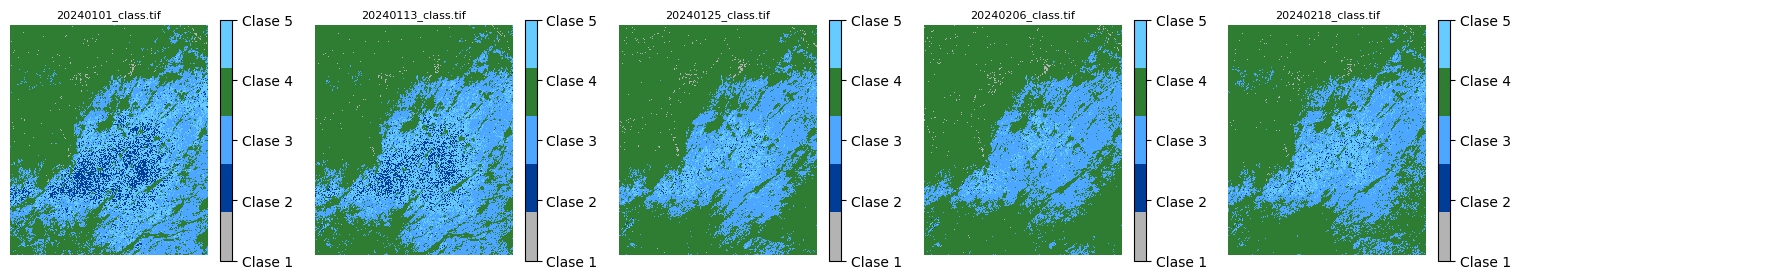

In [ ]:
# Run visualization only on classified rasters
visualizar_kmeans_coloreado("/content/WetSAT/data_cut_dB", class_map=class_map)